# Creates benckmarks for forecasts
The benchmarks to be created are:
- `persistence`: assumes that the last "observed" value is maintained
- `climatology`: assumes a probability distribution derived from a smoothed periodinal analysis

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px
from performance import plotly_forecasting as go_d
from performance import ForecastPerformance

test_dataset_path = Path(r'tests\test_datasets_daily')

obs = pd.read_parquet(test_dataset_path / 'obs.parquet')
display(obs.head(5))

,Q
event_datetime,
2016-10-06,889.21256
2016-10-07,881.77048
2016-10-08,872.04598
2016-10-09,855.84720
2016-10-10,868.49997


## Persistence
Created for specific leadtimes.

In [2]:
fp = ForecastPerformance(obs)
persistence = fp.get_persistence(leadtimes=pd.timedelta_range('0D', '10D', freq='1D')).stack().to_frame(name='Q')
index = persistence.index.to_frame(index=False)
index.loc[:, 'event_datetime'] = index.sum(axis=1)
persistence.index = pd.MultiIndex.from_frame(index)
display(persistence)

TypeError: unsupported operand type(s) for +: 'Timestamp' and 'Timestamp'

In [ ]:
fig = go.Figure()
go_d.plot_lt_deterministic(fig, persistence, colorscale=px.colors.sequential.Magma, showlegend=False)
go_d.add_observed_trace(fig, obs, showlegend=False)
go_d.apply_default_layout(fig, yaxis_title="Q [m3/s]")

## Climatology
The `rolling_window` must be adjusted to balance representativeness and residual noise.  
Is the same for all leadtimes.

In [8]:
climatology = fp.get_climatology(rolling_window=30)
display(climatology)

fig = go.Figure()
go_d.plot_lt_probabilistic(fig, climatology, colorscale=px.colors.sequential.Rainbow)
go_d.add_observed_trace(fig, obs, showlegend=False)
go_d.apply_default_layout(fig, yaxis_title="Q [m3/s]")

values
production_datetime event_datetime leadtime non_exceedance             
2016-10-06          2016-10-06     0 days   0.01             390.979019
                                            0.05             526.862901
                                            0.10             696.717754
                                            0.20             906.414864
                                            0.30            1027.277002
...                                                                 ...
2024-10-26          2024-10-26     0 days   0.70            1651.613712
                                            0.80            1781.343230
                                            0.90            1896.963914
                                            0.95            1958.604219
                                            0.99            2007.916462

[38259 rows x 1 columns]

,uniform,p_values,leadtime
0,0.000000,0.0,0 days
1,0.000354,0.0,0 days
2,0.000707,0.0,0 days
3,0.001061,0.0,0 days
4,0.001414,0.0,0 days
...,...,...,...
2824,0.998586,1.0,0 days
2825,0.998939,1.0,0 days
2826,0.999293,1.0,0 days
2827,0.999646,1.0,0 days


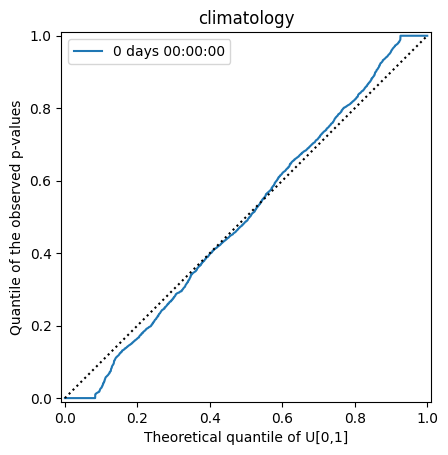

In [9]:
fp.add(climatology, name='climatology')
qq = fp.qq_plot('climatology', plot=True)
display(qq)